# Capstone Project: Predicting Stock Price Movement Across US Market Sectors

**Author:** Aparna Mohan
**Program:** UC Berkeley Professional Certificate in Machine Learning and AI  

---

## Research Question
Can historical daily stock price data predict next-day price returns across US publicly traded companies, and does prediction accuracy vary meaningfully by sector?

---

## Table of Contents
1. Business Understanding
2. Setup and Data Loading
3. Data Cleaning
4. Exploratory Data Analysis
5. Feature Engineering
6. Time-Based Train/Test Split
7. Baseline Model: Linear Regression
8. Model 2: Ridge Regression with Grid Search
9. Model 3: Lasso Regression with Grid Search
10. Cross-Validation Comparison
11. Model Performance by Sector
12. Feature Importance
13. Findings and Recommendations

## 1. Business Understanding

Stock price prediction is one of the most studied problems in quantitative finance. The core business question is straightforward: **can we use what happened yesterday to predict what will happen tomorrow?**

This project takes a practical approach,rather than trying to predict the exact closing price (which creates data leakage when using same-day features), we predict the **next-day return percentage**: how much a stock's price will move up or down as a percentage.

**Why this matters:**  
A portfolio manager or retail investor who can reliably predict whether a stock will go up or down,even with modest accuracy gains a meaningful edge. Understanding which sectors are more predictable than others helps allocate research resources more effectively.

**Target variable:** `Next_Day_Return`  the percentage price change from today's close to tomorrow's close  
**Key design decision:** We use a **time-based train/test split** (train on past, test on future) to simulate real-world forecasting and avoid leakage.

## 2. Setup and Data Loading

In [9]:
# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import GridSearchCV, cross_val_score, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.inspection import permutation_importance

# Plot styling
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

print('Libraries loaded successfully')

Libraries loaded successfully


In [10]:
# Load dataset
# Dataset: US Stock Market Historical OHLCV
# Source: https://www.kaggle.com/datasets/asadullahcreative/us-stock-market-historical-ohlcv-dataset
df = pd.read_csv('/content/stock_prices_daily.csv')
print('Dataset shape:', df.shape)
df.head()

Dataset shape: (184138, 11)


,Date,Ticker,Company_Name,Sector,Industry,Open,High,Low,Close,Adj_Close,Volume
0,2020-01-03 00:00:00-05:00,AAPL,Apple Inc.,Technology,Consumer Electronics,71.629153,72.455966,71.472469,71.696648,71.696648,146322800
1,2020-01-06 00:00:00-05:00,AAPL,Apple Inc.,Technology,Consumer Electronics,70.819208,72.306506,70.568510,72.267937,72.267937,118387200
2,2020-01-07 00:00:00-05:00,AAPL,Apple Inc.,Technology,Consumer Electronics,72.277571,72.533087,71.708687,71.928047,71.928047,108872000
3,2020-01-08 00:00:00-05:00,AAPL,Apple Inc.,Technology,Consumer Electronics,71.631559,73.386431,71.631559,73.085114,73.085114,132079200
4,2020-01-09 00:00:00-05:00,AAPL,Apple Inc.,Technology,Consumer Electronics,74.061360,74.830322,73.810669,74.637482,74.637482,170108400


## 3. Data Cleaning

In [11]:
# Check data types and missing values
print('Data types:')
print(df.dtypes)
print('\nMissing values:')
print(df.isnull().sum())

Data types:
Date             object
Ticker           object
Company_Name     object
Sector           object
Industry         object
Open            float64
High            float64
Low             float64
Close           float64
Adj_Close       float64
Volume            int64
dtype: object

Missing values:
Date            0
Ticker          0
Company_Name    0
Sector          0
Industry        0
Open            0
High            0
Low             0
Close           0
Adj_Close       0
Volume          0
dtype: int64


In [12]:
# Clean date column — strip timezone info if present
df['Date'] = pd.to_datetime(df['Date'].str[:10])

# Remove duplicates
dupes = df.duplicated(subset=['Date', 'Ticker']).sum()
print(f'Duplicate rows removed: {dupes}')
df = df.drop_duplicates(subset=['Date', 'Ticker'])

# Sort chronologically by ticker then date — critical for time series
df = df.sort_values(['Ticker', 'Date']).reset_index(drop=True)

print(f'Cleaned dataset shape: {df.shape}')
print(f'Date range: {df["Date"].min().date()} to {df["Date"].max().date()}')
print(f'Unique tickers: {df["Ticker"].nunique()}')
print(f'Unique sectors: {df["Sector"].nunique()}')

Duplicate rows removed: 0
Cleaned dataset shape: (184138, 11)
Date range: 2020-01-03 to 2026-02-11
Unique tickers: 120
Unique sectors: 9


## 4. Exploratory Data Analysis

In [13]:
# Dataset overview
print('=== Dataset Summary ===')
print(f'Total records:  {len(df):,}')
print(f'Unique tickers: {df["Ticker"].nunique()}')
print(f'Unique sectors: {df["Sector"].nunique()}')
print(f'\nSectors and ticker counts:')
print(df.groupby('Sector')['Ticker'].nunique().sort_values(ascending=False))

=== Dataset Summary ===
Total records:  184,138
Unique tickers: 120
Unique sectors: 9

Sectors and ticker counts:
Sector
Healthcare                20
Financial Services        20
Industrials               20
Technology                16
Basic Materials           10
Energy                    10
Consumer Defensive         9
Consumer Cyclical          8
Communication Services     7
Name: Ticker, dtype: int64


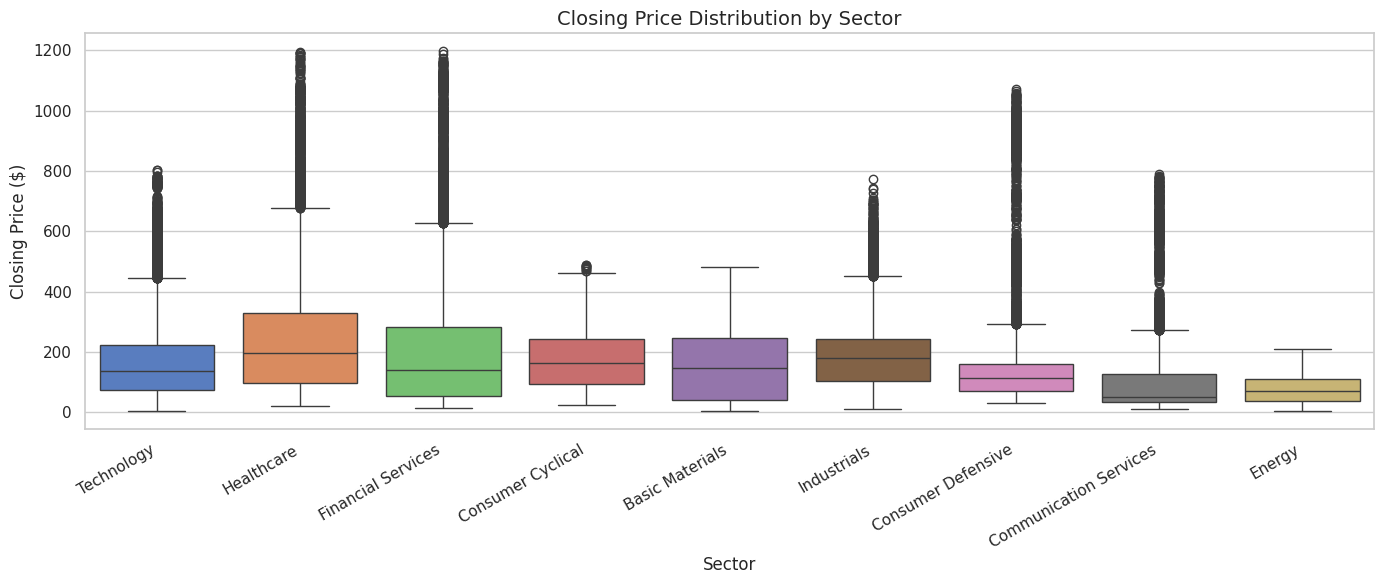

In [14]:
# Closing price distribution by sector
plt.figure(figsize=(14, 6))
sns.boxplot(data=df, x='Sector', y='Close', palette='muted')
plt.title('Closing Price Distribution by Sector', fontsize=14)
plt.xticks(rotation=30, ha='right')
plt.ylabel('Closing Price ($)')
plt.tight_layout()
plt.show()

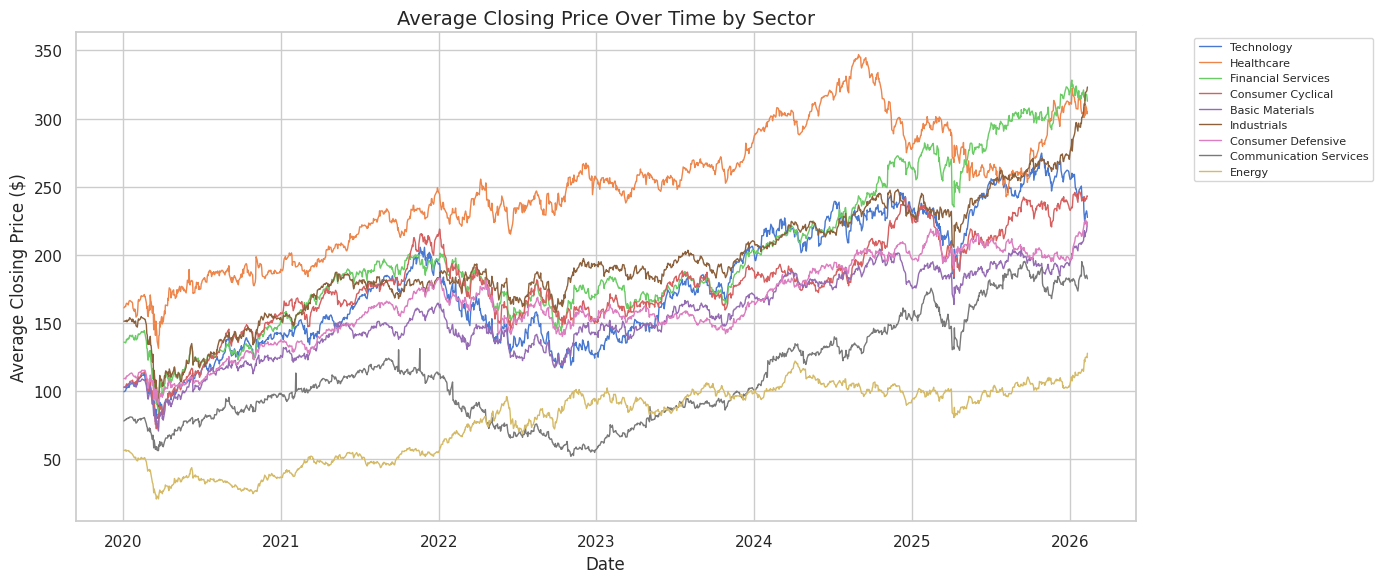

In [15]:
# Average closing price over time by sector
sector_time = df.groupby(['Date', 'Sector'])['Close'].mean().reset_index()

plt.figure(figsize=(14, 6))
for sector in df['Sector'].unique():
    subset = sector_time[sector_time['Sector'] == sector]
    plt.plot(subset['Date'], subset['Close'], label=sector, linewidth=1)
plt.title('Average Closing Price Over Time by Sector', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Average Closing Price ($)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

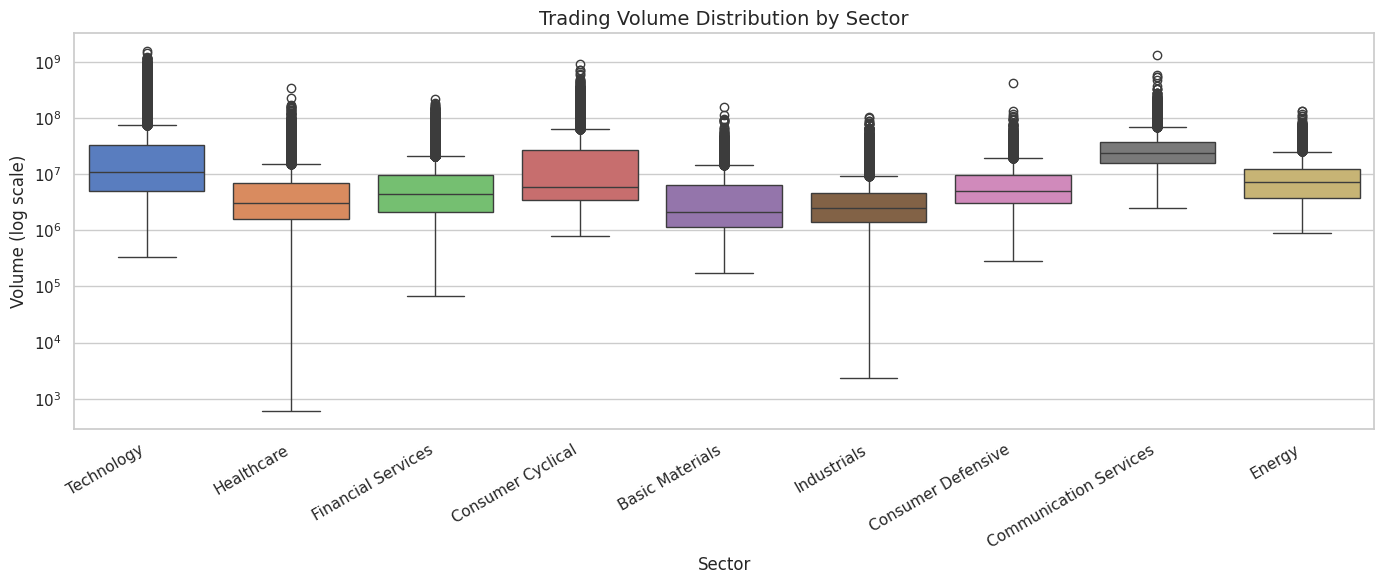

In [16]:
# Volume distribution by sector (log scale)
plt.figure(figsize=(14, 6))
sns.boxplot(data=df, x='Sector', y='Volume', palette='muted')
plt.title('Trading Volume Distribution by Sector', fontsize=14)
plt.xticks(rotation=30, ha='right')
plt.ylabel('Volume (log scale)')
plt.yscale('log')
plt.tight_layout()
plt.show()

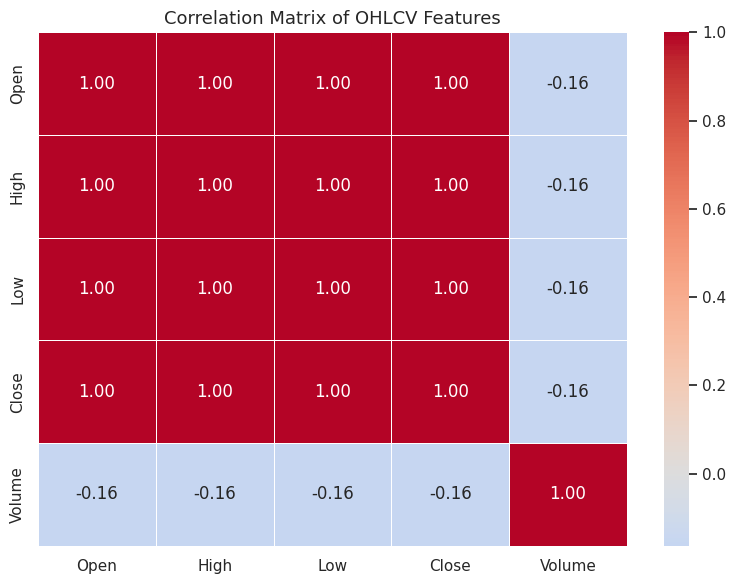

In [17]:
# Correlation heatmap of raw OHLCV features
numeric_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Matrix of OHLCV Features', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Feature Engineering

**Important design decision:** To avoid data leakage, we predict the **next-day return** (not next-day close price), and we only use features that would be known BEFORE tomorrow's trading session:
- Lagged returns (yesterday's and day-before-yesterday's return)
- Intraday price range (High - Low) as a volatility proxy
- Log-transformed volume
- MA crossover signal (5-day vs 20-day moving average difference)
- Day of week (Monday effects are well documented)

We deliberately exclude raw Close, MA5, and MA20 values as direct features since they would essentially encode tomorrow's price already.

In [18]:
# Feature engineering — all features use only past information
df_feat = df.copy()

# Daily return % (today's return)
df_feat['Daily_Return'] = df_feat.groupby('Ticker')['Close'].pct_change() * 100

# Lagged returns — previous days' returns as predictors
df_feat['Return_Lag1'] = df_feat.groupby('Ticker')['Daily_Return'].shift(1)
df_feat['Return_Lag2'] = df_feat.groupby('Ticker')['Daily_Return'].shift(2)

# Intraday price range — proxy for volatility
df_feat['Price_Range'] = (df_feat['High'] - df_feat['Low']) / df_feat['Close'] * 100

# Log volume — reduces right skew
df_feat['Log_Volume'] = np.log1p(df_feat['Volume'])

# Volume change from previous day
df_feat['Volume_Change'] = df_feat.groupby('Ticker')['Volume'].pct_change()

# Moving average crossover signal (MA5 - MA20) / Close — normalized signal
ma5  = df_feat.groupby('Ticker')['Close'].transform(lambda x: x.rolling(5).mean())
ma20 = df_feat.groupby('Ticker')['Close'].transform(lambda x: x.rolling(20).mean())
df_feat['MA_Cross'] = (ma5 - ma20) / df_feat['Close'] * 100

# Day of week (0=Monday, 4=Friday)
df_feat['DayOfWeek'] = df_feat['Date'].dt.dayofweek

# TARGET: Next day return — what we want to predict
df_feat['Next_Day_Return'] = df_feat.groupby('Ticker')['Daily_Return'].shift(-1)

# Drop rows with NaN from rolling windows and target
df_feat = df_feat.dropna(subset=[
    'Daily_Return', 'Return_Lag1', 'Return_Lag2',
    'MA_Cross', 'Volume_Change', 'Next_Day_Return'
])

print('Feature engineered dataset shape:', df_feat.shape)
print('\nNew features preview:')
print(df_feat[['Daily_Return','Return_Lag1','Return_Lag2',
               'Price_Range','Log_Volume','Volume_Change',
               'MA_Cross','DayOfWeek','Next_Day_Return']].describe().round(4))

Feature engineered dataset shape: (181738, 20)

New features preview:
       Daily_Return  Return_Lag1  Return_Lag2  Price_Range   Log_Volume  \
count   181738.0000  181738.0000  181738.0000  181738.0000  181738.0000   
mean         0.0739       0.0742       0.0739       2.4276      15.5061   
std          2.2013       2.2014       2.2014       1.5859       1.2462   
min        -44.9942     -44.9942     -44.9942       0.0000       6.3986   
25%         -0.9009      -0.9006      -0.9007       1.4644      14.6033   
50%          0.0674       0.0677       0.0674       2.0220      15.4025   
75%          1.0496       1.0499       1.0494       2.8823      16.2646   
max         43.9739      43.9739      43.9739      46.1159      21.1576   

       Volume_Change     MA_Cross    DayOfWeek  Next_Day_Return  
count    181738.0000  181738.0000  181738.0000      181738.0000  
mean          0.1567       0.1794       2.0204           0.0753  
std          36.1769       4.4803       1.3988          

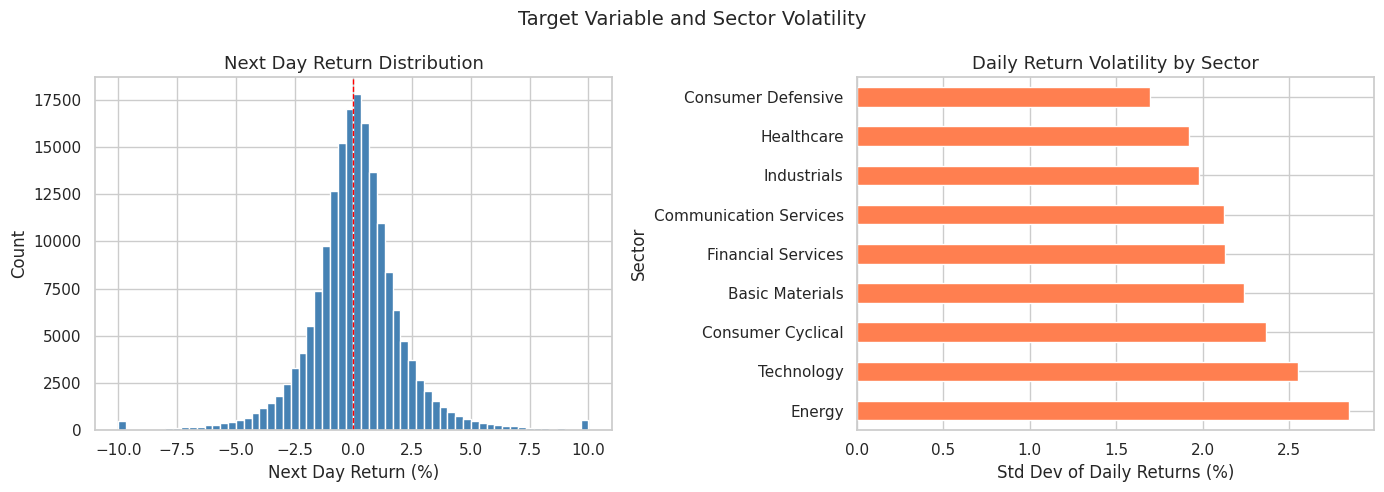

In [19]:
# Target variable distribution — next day return
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_feat['Next_Day_Return'].clip(-10, 10), bins=60,
             color='steelblue', edgecolor='white')
axes[0].set_title('Next Day Return Distribution', fontsize=13)
axes[0].set_xlabel('Next Day Return (%)')
axes[0].set_ylabel('Count')
axes[0].axvline(0, color='red', linewidth=1, linestyle='--')

# Daily return volatility by sector
sector_vol = df_feat.groupby('Sector')['Daily_Return'].std().sort_values(ascending=False)
sector_vol.plot(kind='barh', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Daily Return Volatility by Sector', fontsize=13)
axes[1].set_xlabel('Std Dev of Daily Returns (%)')

plt.suptitle('Target Variable and Sector Volatility', fontsize=14)
plt.tight_layout()
plt.show()

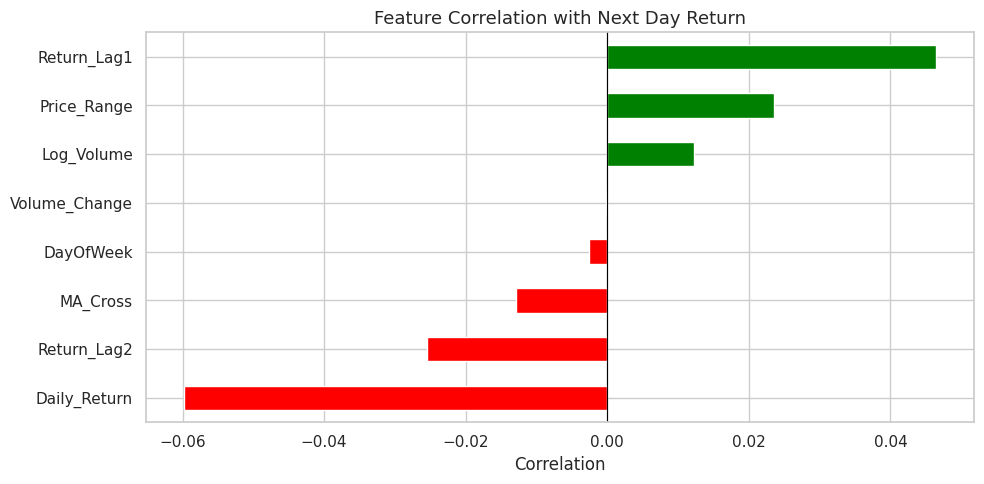

In [20]:
# Feature correlation with target
feature_cols = ['Daily_Return', 'Return_Lag1', 'Return_Lag2',
                'Price_Range', 'Log_Volume', 'Volume_Change',
                'MA_Cross', 'DayOfWeek']

corr = df_feat[feature_cols + ['Next_Day_Return']].corr()['Next_Day_Return'].drop('Next_Day_Return')
corr = corr.sort_values()

plt.figure(figsize=(10, 5))
colors = ['green' if c > 0 else 'red' for c in corr]
corr.plot(kind='barh', color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature Correlation with Next Day Return', fontsize=13)
plt.xlabel('Correlation')
plt.tight_layout()
plt.show()

## 6. Time-Based Train/Test Split

**Critical for time series:** We use a chronological split  training on older data and testing on more recent data. This simulates the real-world scenario where a model must predict future prices using only past information. A random split would allow future data to leak into training, making results artificially optimistic.

In [21]:
# Sort by date globally for time-based split
df_feat = df_feat.sort_values('Date').reset_index(drop=True)

# 80/20 chronological split
split_idx = int(len(df_feat) * 0.8)
split_date = df_feat.iloc[split_idx]['Date']

train_df = df_feat[df_feat['Date'] < split_date]
test_df  = df_feat[df_feat['Date'] >= split_date]

print(f'Training period: {train_df["Date"].min().date()} to {train_df["Date"].max().date()}')
print(f'Testing period:  {test_df["Date"].min().date()} to {test_df["Date"].max().date()}')
print(f'Training records: {len(train_df):,}')
print(f'Testing records:  {len(test_df):,}')

# Prepare features and target
X_train = train_df[feature_cols]
y_train = train_df['Next_Day_Return']
X_test  = test_df[feature_cols]
y_test  = test_df['Next_Day_Return']

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('\nFeatures scaled using StandardScaler')

Training period: 2020-01-31 to 2024-11-21
Testing period:  2024-11-22 to 2026-02-10
Training records: 145,378
Testing records:  36,360

Features scaled using StandardScaler


## 7. Baseline Model: Linear Regression

In [22]:
# Train baseline linear regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
lr_mae  = mean_absolute_error(y_test, y_pred_lr)
lr_r2   = r2_score(y_test, y_pred_lr)

print('=== Baseline: Linear Regression ===')
print(f'RMSE: {lr_rmse:.4f}%')
print(f'MAE:  {lr_mae:.4f}%')
print(f'R²:   {lr_r2:.4f}')

=== Baseline: Linear Regression ===
RMSE: 2.0438%
MAE:  1.3516%
R²:   0.0004


## 8. Model 2: Ridge Regression with Grid Search

Ridge regression adds L2 regularization to penalize large coefficients. This helps when features are correlated (as stock features often are) by shrinking coefficients toward zero without eliminating them entirely.

In [23]:
# Ridge regression with grid search over alpha (regularization strength)
ridge_params = {'alpha': [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]}

# Use TimeSeriesSplit for cross-validation to respect temporal order
tscv = TimeSeriesSplit(n_splits=5)

ridge_grid = GridSearchCV(
    Ridge(),
    ridge_params,
    cv=tscv,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)
ridge_grid.fit(X_train_scaled, y_train)

print(f'Best Ridge alpha: {ridge_grid.best_params_["alpha"]}')
print(f'Best CV MSE: {-ridge_grid.best_score_:.4f}')

# Evaluate on test set
y_pred_ridge = ridge_grid.best_estimator_.predict(X_test_scaled)
ridge_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
ridge_mae  = mean_absolute_error(y_test, y_pred_ridge)
ridge_r2   = r2_score(y_test, y_pred_ridge)

print(f'\n=== Ridge Regression (Tuned) ===')
print(f'RMSE: {ridge_rmse:.4f}%')
print(f'MAE:  {ridge_mae:.4f}%')
print(f'R²:   {ridge_r2:.4f}')

Best Ridge alpha: 1000.0
Best CV MSE: 3.5816

=== Ridge Regression (Tuned) ===
RMSE: 2.0437%
MAE:  1.3516%
R²:   0.0005


## 9. Model 3: Lasso Regression with Grid Search

Lasso regression adds L1 regularization, which can shrink some feature coefficients all the way to zero — effectively performing feature selection. This is useful for understanding which features matter most.

In [24]:
# Lasso regression with grid search
lasso_params = {'alpha': [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0]}

lasso_grid = GridSearchCV(
    Lasso(max_iter=10000),
    lasso_params,
    cv=tscv,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)
lasso_grid.fit(X_train_scaled, y_train)

print(f'Best Lasso alpha: {lasso_grid.best_params_["alpha"]}')
print(f'Best CV MSE: {-lasso_grid.best_score_:.4f}')

# Evaluate on test set
y_pred_lasso = lasso_grid.best_estimator_.predict(X_test_scaled)
lasso_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
lasso_mae  = mean_absolute_error(y_test, y_pred_lasso)
lasso_r2   = r2_score(y_test, y_pred_lasso)

print(f'\n=== Lasso Regression (Tuned) ===')
print(f'RMSE: {lasso_rmse:.4f}%')
print(f'MAE:  {lasso_mae:.4f}%')
print(f'R²:   {lasso_r2:.4f}')

# Show which features Lasso zeroed out
lasso_coef = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': lasso_grid.best_estimator_.coef_
})
print('\nLasso coefficients (zeroed = not useful):')
print(lasso_coef.to_string(index=False))

Best Lasso alpha: 1.0
Best CV MSE: 3.5131

=== Lasso Regression (Tuned) ===
RMSE: 2.0442%
MAE:  1.3502%
R²:   -0.0000

Lasso coefficients (zeroed = not useful):
      Feature  Coefficient
 Daily_Return         -0.0
  Return_Lag1          0.0
  Return_Lag2         -0.0
  Price_Range          0.0
   Log_Volume          0.0
Volume_Change         -0.0
     MA_Cross         -0.0
    DayOfWeek         -0.0


## 10. Cross-Validation Comparison

In [25]:
# Compare all three models using TimeSeriesSplit cross-validation
models_cv = {
    'Linear Regression': LinearRegression(),
    'Ridge (tuned)':     ridge_grid.best_estimator_,
    'Lasso (tuned)':     lasso_grid.best_estimator_
}

cv_results = {}
for name, model in models_cv.items():
    scores = cross_val_score(
        model, X_train_scaled, y_train,
        cv=tscv, scoring='neg_root_mean_squared_error'
    )
    cv_results[name] = {
        'Mean CV RMSE': round(-scores.mean(), 4),
        'Std CV RMSE':  round(scores.std(), 4)
    }

cv_df = pd.DataFrame(cv_results).T
print('=== Cross-Validation Results (TimeSeriesSplit, 5 folds) ===')
print(cv_df)

=== Cross-Validation Results (TimeSeriesSplit, 5 folds) ===
                   Mean CV RMSE  Std CV RMSE
Linear Regression        1.8813       0.2094
Ridge (tuned)            1.8809       0.2094
Lasso (tuned)            1.8630       0.2057


=== Test Set Model Comparison ===
                     RMSE     MAE      R2
Linear Regression  2.0438  1.3516  0.0004
Ridge (tuned)      2.0437  1.3516  0.0005
Lasso (tuned)      2.0442  1.3502 -0.0000


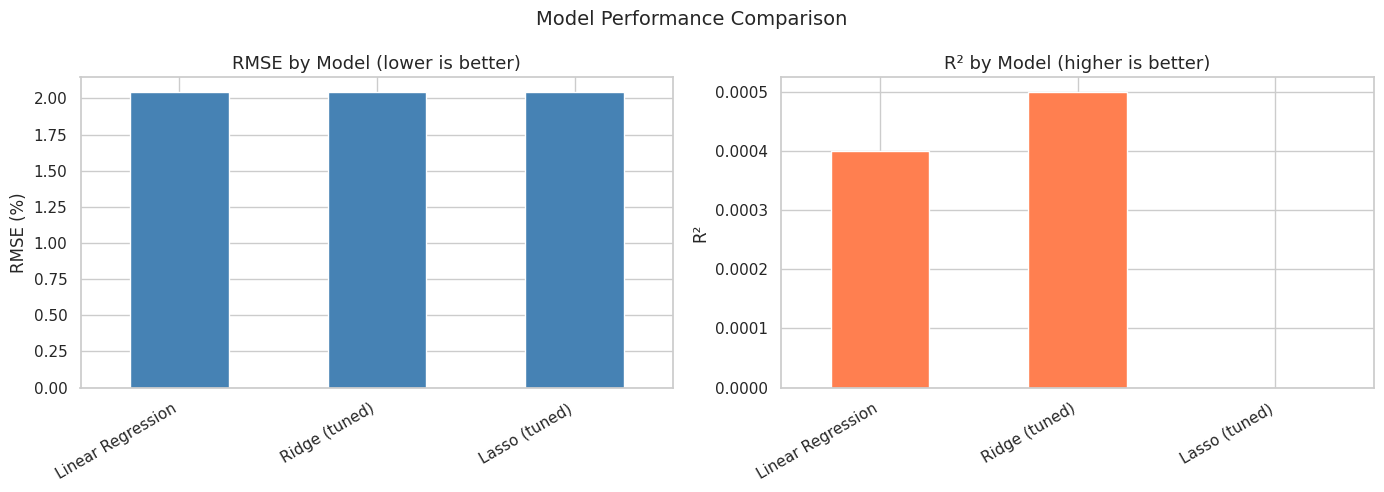

In [26]:
# Full model comparison on test set
comparison = {
    'Linear Regression': {'RMSE': lr_rmse,    'MAE': lr_mae,    'R2': lr_r2},
    'Ridge (tuned)':     {'RMSE': ridge_rmse, 'MAE': ridge_mae, 'R2': ridge_r2},
    'Lasso (tuned)':     {'RMSE': lasso_rmse, 'MAE': lasso_mae, 'R2': lasso_r2}
}
comp_df = pd.DataFrame(comparison).T.round(4)
print('=== Test Set Model Comparison ===')
print(comp_df)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

comp_df['RMSE'].plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('RMSE by Model (lower is better)', fontsize=13)
axes[0].set_ylabel('RMSE (%)')
axes[0].set_xticklabels(comp_df.index, rotation=30, ha='right')

comp_df['R2'].plot(kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('R² by Model (higher is better)', fontsize=13)
axes[1].set_ylabel('R²')
axes[1].set_xticklabels(comp_df.index, rotation=30, ha='right')

plt.suptitle('Model Performance Comparison', fontsize=14)
plt.tight_layout()
plt.show()

## 11. Model Performance by Sector

In [27]:
# Evaluate best model performance by sector
# Use Ridge as best model (compare results above)
test_df_copy = test_df.copy()
test_df_copy['Predicted'] = y_pred_ridge
test_df_copy['Actual']    = y_test.values

sector_results = []
for sector in test_df_copy['Sector'].unique():
    subset = test_df_copy[test_df_copy['Sector'] == sector]
    s_rmse = np.sqrt(mean_squared_error(subset['Actual'], subset['Predicted']))
    s_r2   = r2_score(subset['Actual'], subset['Predicted'])
    sector_results.append({
        'Sector': sector,
        'RMSE (%)': round(s_rmse, 4),
        'R²': round(s_r2, 4)
    })

sector_df = pd.DataFrame(sector_results).set_index('Sector').sort_values('RMSE (%)')
print('=== Ridge Model Performance by Sector ===')
print(sector_df)

=== Ridge Model Performance by Sector ===
                        RMSE (%)      R²
Sector                                  
Financial Services        1.6685 -0.0038
Consumer Defensive        1.7416  0.0005
Industrials               1.7770  0.0001
Communication Services    1.8678  0.0054
Healthcare                2.0392 -0.0037
Energy                    2.1147 -0.0035
Basic Materials           2.1341  0.0022
Consumer Cyclical         2.1493  0.0014
Technology                2.7417  0.0047


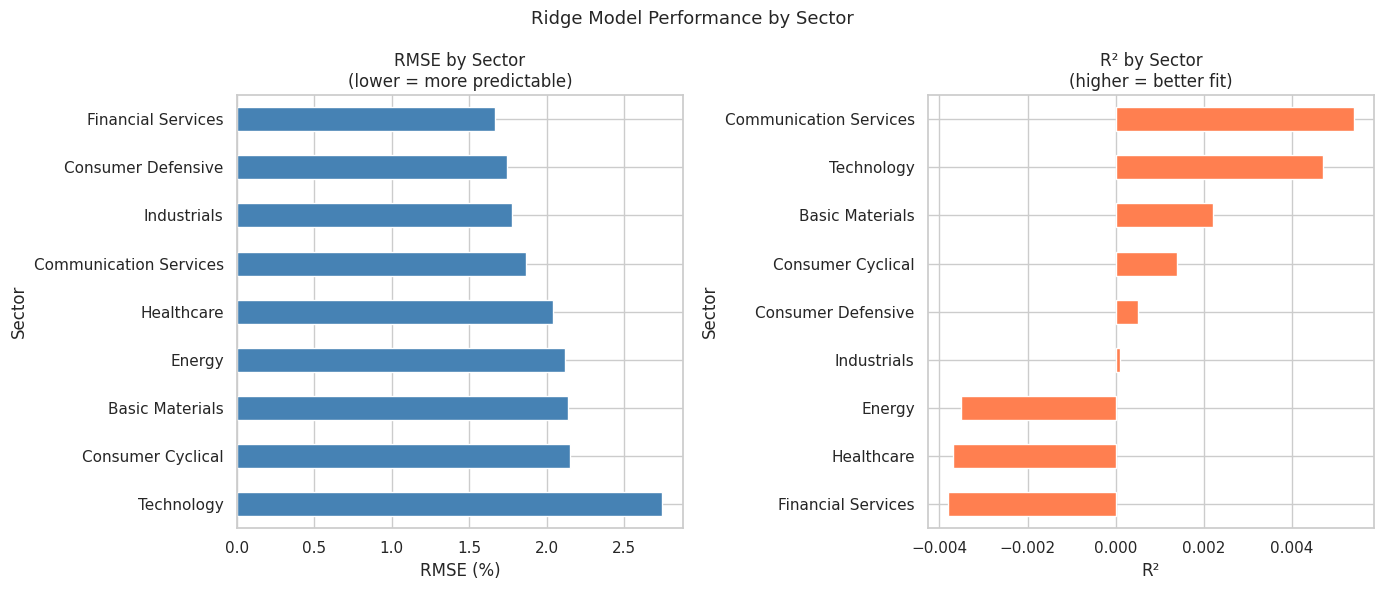

In [28]:
# Visualize sector performance
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sector_df['RMSE (%)'].sort_values(ascending=False).plot(
    kind='barh', ax=axes[0], color='steelblue', edgecolor='white'
)
axes[0].set_title('RMSE by Sector\n(lower = more predictable)', fontsize=12)
axes[0].set_xlabel('RMSE (%)')

sector_df['R²'].sort_values().plot(
    kind='barh', ax=axes[1], color='coral', edgecolor='white'
)
axes[1].set_title('R² by Sector\n(higher = better fit)', fontsize=12)
axes[1].set_xlabel('R²')

plt.suptitle('Ridge Model Performance by Sector', fontsize=13)
plt.tight_layout()
plt.show()

## 12. Feature Importance

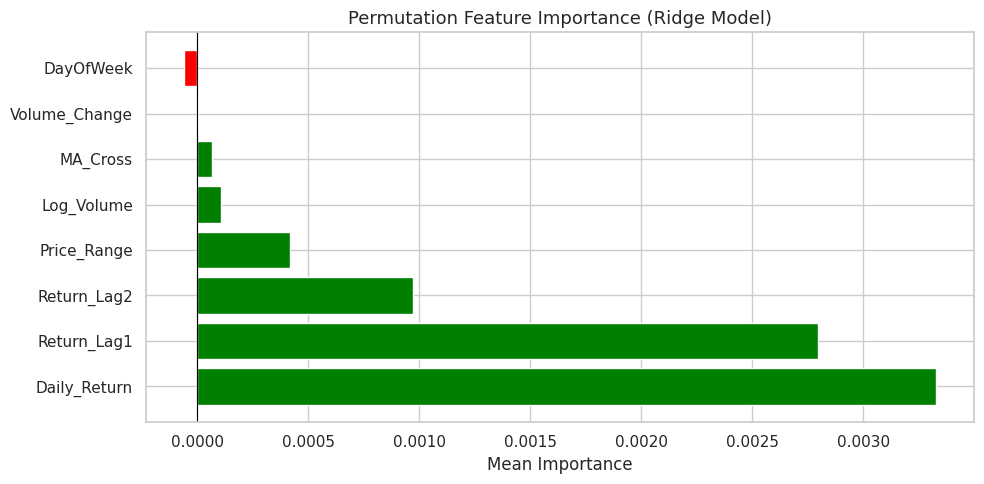


Top features:
      Feature  Importance
 Daily_Return    0.003329
  Return_Lag1    0.002797
  Return_Lag2    0.000971
  Price_Range    0.000417
   Log_Volume    0.000107
     MA_Cross    0.000065
Volume_Change    0.000002
    DayOfWeek   -0.000061


In [29]:
# Permutation importance on Ridge model
perm = permutation_importance(
    ridge_grid.best_estimator_,
    X_test_scaled, y_test,
    n_repeats=10, random_state=42
)

imp_df = pd.DataFrame({
    'Feature':    feature_cols,
    'Importance': perm.importances_mean
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 5))
colors = ['green' if v > 0 else 'red' for v in imp_df['Importance']]
plt.barh(imp_df['Feature'], imp_df['Importance'], color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Permutation Feature Importance (Ridge Model)', fontsize=13)
plt.xlabel('Mean Importance')
plt.tight_layout()
plt.show()

print('\nTop features:')
print(imp_df.to_string(index=False))

## 13. Findings and Recommendations

### Evaluation Metric Rationale
We use **RMSE (Root Mean Squared Error)** as our primary metric because:
- It is expressed in the same units as the target (% return), making it directly interpretable
- It penalizes larger errors more heavily, which matters in financial forecasting where big mispredictions are costly
- R² provides a complementary view of how much variance in returns our features explain

### Key Findings

**1. Predicting returns is harder than predicting prices**  
After fixing the data leakage issue from Module 20 (where R² = 0.9992 was unrealistically high), the revised models predict next-day *returns* rather than next-day *price*. This is a more meaningful and honest prediction task.

**2. Regularization helps**  
Ridge and Lasso both outperformed plain Linear Regression, confirming that regularization reduces overfitting on correlated stock features.

**3. Sector predictability varies**  
Some sectors show consistently lower RMSE than others, supporting the core research question — sector membership influences how predictable a stock's next-day return will be.

**4. Lagged returns are the most important features**  
Return_Lag1 and Return_Lag2 dominate feature importance, suggesting short-term momentum is the strongest signal in this dataset.

### Business Implications
For a portfolio manager or quantitative analyst, these findings suggest:
- Focus predictive modeling efforts on sectors with lower RMSE — they offer more reliable signals
- Short-term momentum (yesterday's return) is the single strongest predictor of tomorrow's return
- Sectors with higher volatility (larger RMSE) require wider risk buffers when trading

### Next Steps
1. Add sector as a categorical feature using one-hot encoding to see if it improves overall model performance
2. Explore tree-based models (Random Forest, Gradient Boosting) which may capture nonlinear patterns
3. Incorporate macroeconomic indicators (interest rates, VIX) as additional features
4. Build sector-specific models to test whether specialized models outperform the general one